In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

In [2]:
movies_clean_df = pd.read_csv("data_movies_cleaned.csv")

In [3]:
movies_clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TMDb_ID        815 non-null    int64  
 1   IMDb_ID        815 non-null    str    
 2   Title          815 non-null    str    
 3   Year           815 non-null    int64  
 4   Genre          815 non-null    str    
 5   Primary Genre  815 non-null    str    
 6   TMDb Rating    815 non-null    float64
 7   TMDb Votes     815 non-null    int64  
 8   Popularity     815 non-null    float64
 9   Revenue        553 non-null    float64
 10  Budget         547 non-null    float64
 11  Runtime        815 non-null    int64  
 12  IMDb Rating    687 non-null    float64
 13  IMDb Votes     702 non-null    float64
 14  Box Office     498 non-null    float64
dtypes: float64(7), int64(4), str(4)
memory usage: 139.8 KB


In [4]:
movies_clean_df.describe()

,TMDb_ID,Year,TMDb Rating,TMDb Votes,Popularity,Revenue,Budget,Runtime,IMDb Rating,IMDb Votes,Box Office
count,8.150000e+02,815.000000,815.000000,815.000000,815.000000,5.530000e+02,5.470000e+02,815.00000,687.000000,7.020000e+02,4.980000e+02
mean,6.877341e+05,2018.693252,6.631811,5624.483436,28.820767,3.906051e+08,9.584158e+07,115.31411,6.733624,3.077750e+05,1.545897e+08
std,5.520892e+05,7.768559,1.619122,7459.699744,50.437862,4.366907e+08,8.617554e+07,31.29309,1.196297,4.197203e+05,1.597658e+08
min,1.200000e+01,2000.000000,0.000000,0.000000,6.470200,2.000000e+00,1.000000e+00,0.00000,2.100000,9.000000e+00,6.341000e+03
25%,1.229115e+05,2013.000000,6.200000,70.000000,11.342600,5.393364e+07,2.100000e+07,99.00000,6.100000,1.309125e+04,2.608055e+07
50%,5.946690e+05,2022.000000,6.998000,1876.000000,15.195700,2.457246e+08,7.850000e+07,114.00000,6.900000,1.326215e+05,1.094505e+08
75%,1.228478e+06,2025.500000,7.560000,9114.500000,24.497200,5.990460e+08,1.500000e+08,133.00000,7.600000,4.734432e+05,2.186316e+08
max,1.706197e+06,2026.000000,10.000000,40044.000000,581.755400,2.923706e+09,6.588000e+08,254.00000,9.300000,3.161907e+06,9.366622e+08


<Axes: xlabel='Primary Genre'>

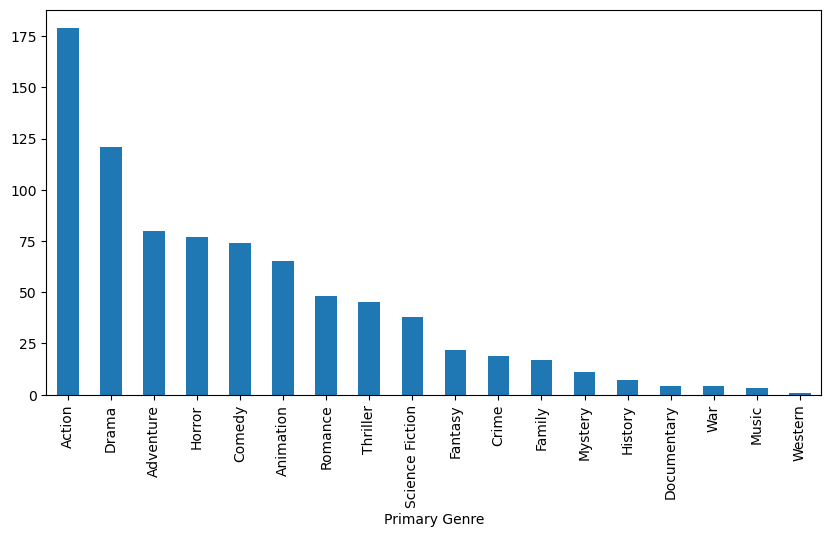

In [5]:
movies_clean_df["Primary Genre"].value_counts().plot.bar(figsize=(10,5))

In [6]:
eda_df = movies_clean_df.copy()

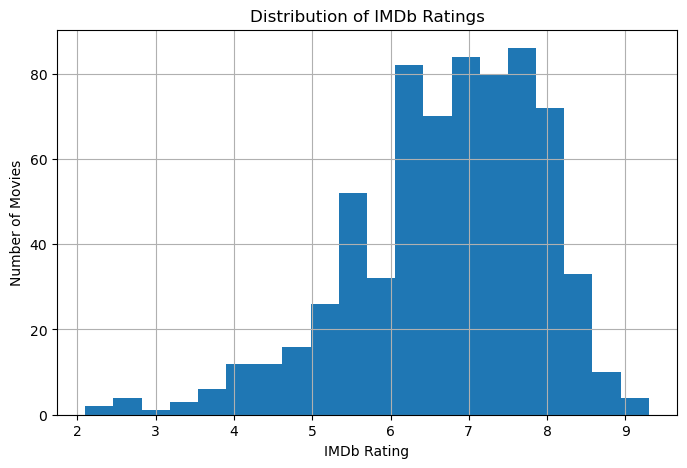

In [7]:
#Distribution of IMDb Ratings
#Purpose
#Understand how ratings are distributed.
plt.figure(figsize=(8, 5))

eda_df["IMDb Rating"].dropna().hist(
    bins=20
)

plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of IMDb Ratings")

plt.show()

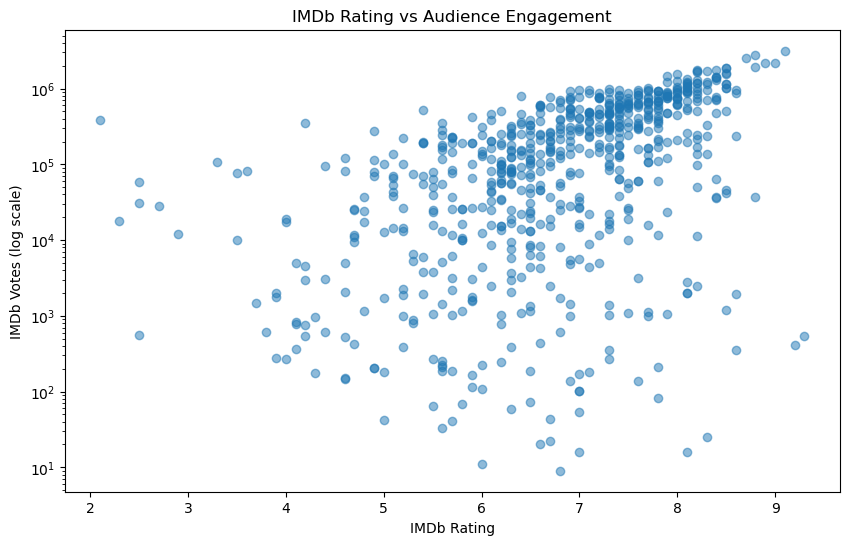

In [8]:
#IMDb Rating vs IMDb Votes
#Purpose
#Test whether higher-rated movies receive more audience participation.

rating_votes_df = eda_df.dropna(
    subset=["IMDb Rating", "IMDb Votes"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    rating_votes_df["IMDb Rating"],
    rating_votes_df["IMDb Votes"],
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("IMDb Rating")
plt.ylabel("IMDb Votes (log scale)")
plt.title("IMDb Rating vs Audience Engagement")

plt.show()

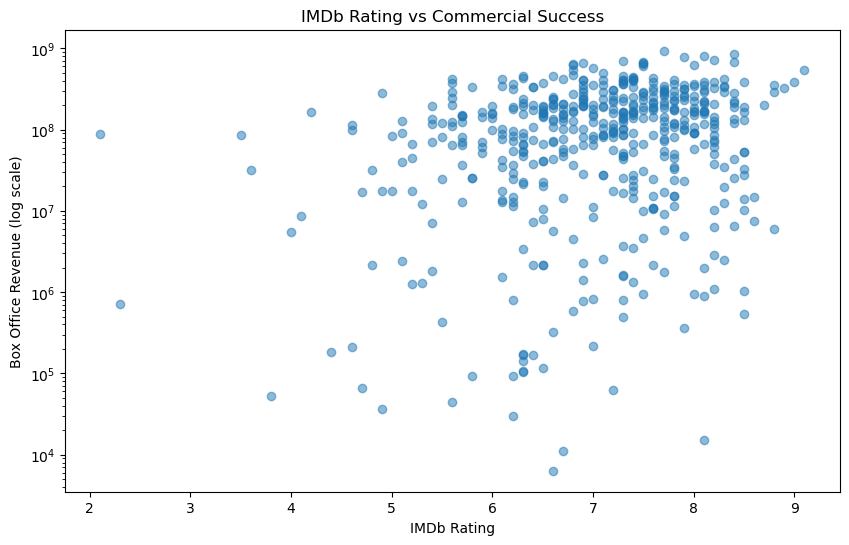

In [9]:
#IMDb Rating vs Box Office
#Purpose
#Test whether higher-rated movies achieve greater commercial success.
rating_box_df = eda_df.dropna(
    subset=["IMDb Rating", "Box Office"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    rating_box_df["IMDb Rating"],
    rating_box_df["Box Office"],
    alpha=0.5
)

plt.yscale("log")

plt.xlabel("IMDb Rating")
plt.ylabel("Box Office Revenue (log scale)")
plt.title("IMDb Rating vs Commercial Success")

plt.show()

In [10]:
#Correlation Heatmap
#Purpose
#Identify the strongest relationships in the dataset.
corr_df = eda_df[
    [
        "IMDb Rating",
        "TMDb Rating",
        "IMDb Votes",
        "TMDb Votes",
        "Popularity",
        "Revenue",
        "Budget",
        "Runtime",
        "Box Office"
    ]
]

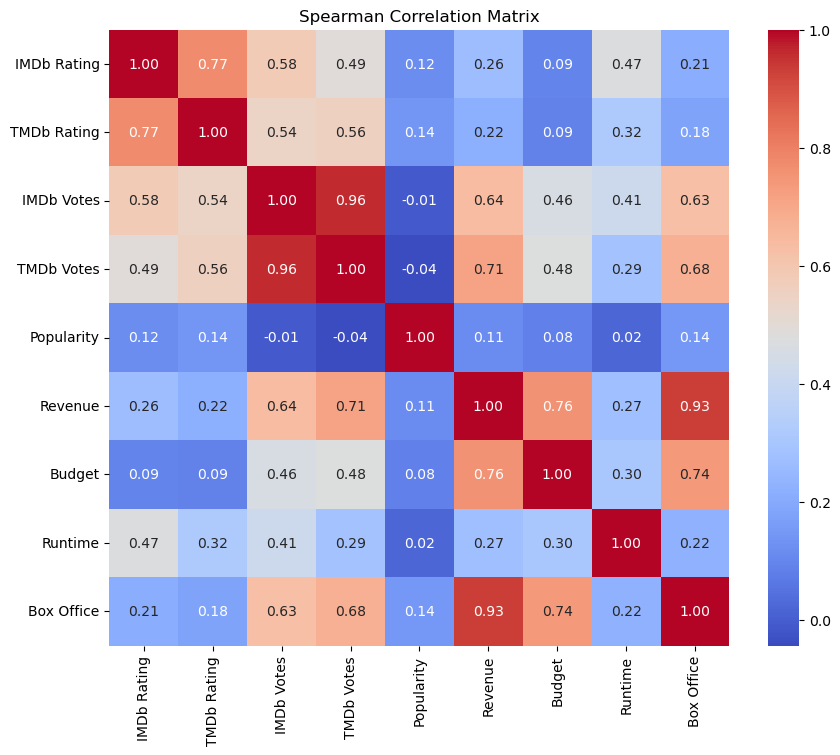

In [11]:
#Why Spearman?
#Revenue and vote counts are highly skewed, so Spearman is more robust than Pearson.

corr = corr_df.corr(
    method="spearman"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Spearman Correlation Matrix")

plt.show()

In [12]:
#Genre Comparison

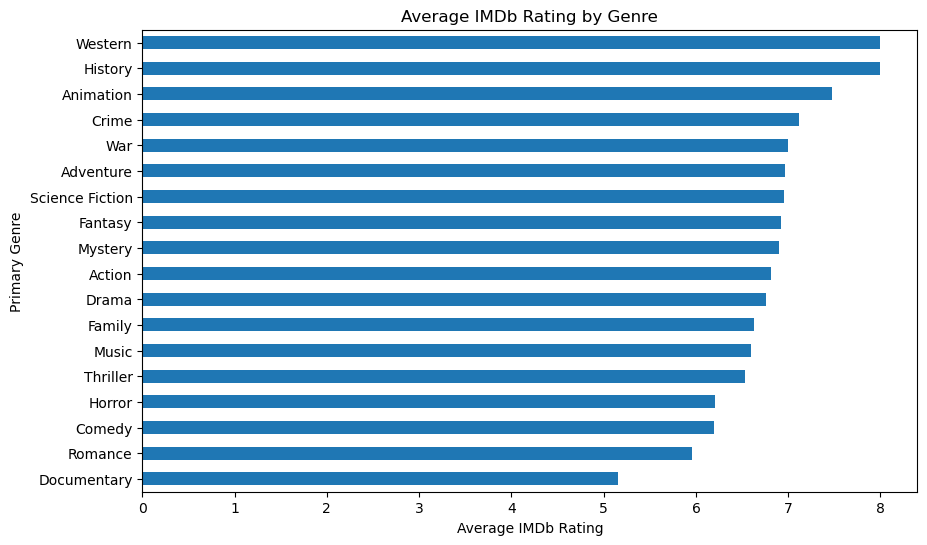

In [13]:
#Average IMDb Rating by Genre
genre_rating = (
    eda_df.groupby("Primary Genre")
    ["IMDb Rating"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

genre_rating.plot(
    kind="barh"
)

plt.xlabel("Average IMDb Rating")
plt.title("Average IMDb Rating by Genre")

plt.show()

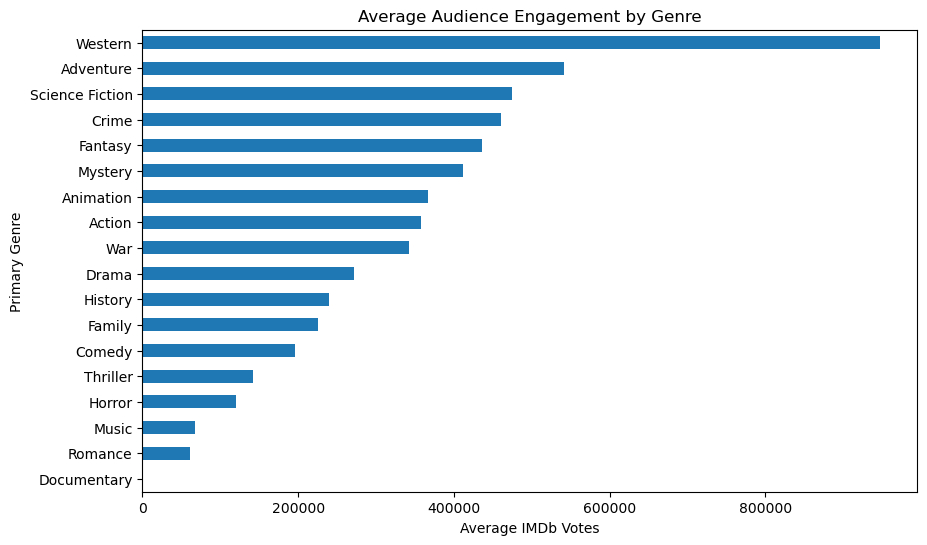

In [14]:
#Average IMDb Votes by Genre
genre_votes = (
    eda_df.groupby("Primary Genre")
    ["IMDb Votes"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

genre_votes.plot(
    kind="barh"
)

plt.xlabel("Average IMDb Votes")
plt.title("Average Audience Engagement by Genre")

plt.show()

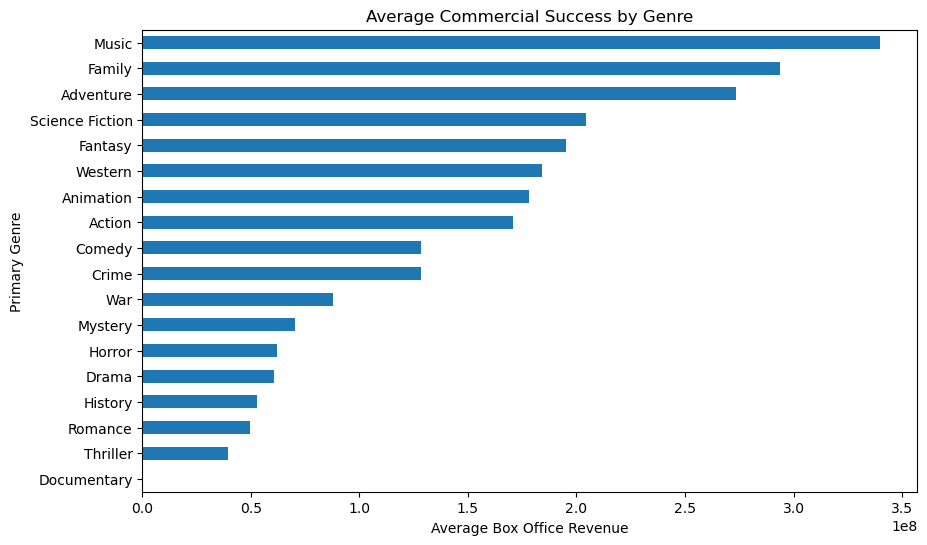

In [15]:
#verage Box Office by Genre
genre_box = (
    eda_df.groupby("Primary Genre")
    ["Box Office"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

genre_box.plot(
    kind="barh"
)

plt.xlabel("Average Box Office Revenue")
plt.title("Average Commercial Success by Genre")

plt.show()

In [16]:
#Correlations

In [17]:
#Rating vs Votes
rho_votes, p_votes = spearmanr(
    rating_votes_df["IMDb Rating"],
    rating_votes_df["IMDb Votes"]
)

print(
    f"Rating vs Votes: rho={rho_votes:.3f}, p={p_votes:.5f}"
)

Rating vs Votes: rho=0.580, p=0.00000


In [18]:
#Movies with higher IMDb ratings tend to receive substantially more audience votes.

In [19]:
#Rating vs Revenue
rho_box, p_box = spearmanr(
    rating_box_df["IMDb Rating"],
    rating_box_df["Box Office"]
)

print(
    f"Rating vs Box Office: rho={rho_box:.3f}, p={p_box:.5f}"
)

Rating vs Box Office: rho=0.211, p=0.00000


In [20]:
#Higher-rated movies earn somewhat more revenue on average, but the relationship is much weaker than for audience engagement.
#Audience approval alone is not a strong predictor of commercial success.

In [21]:
spearmanr(eda_df["IMDb Rating"], eda_df["Popularity"])

SignificanceResult(statistic=nan, pvalue=nan)

In [22]:
spearmanr(eda_df["IMDb Rating"], eda_df["TMDb Votes"])

SignificanceResult(statistic=nan, pvalue=nan)

In [23]:
#Check missing values
eda_df[["IMDb Rating", "Popularity"]].isna().sum()

IMDb Rating    128
Popularity       0
dtype: int64

In [24]:
#Check missing values
eda_df[["IMDb Rating", "TMDb Votes"]].isna().sum()

IMDb Rating    128
TMDb Votes       0
dtype: int64

In [25]:
eda_df[[
    "IMDb Rating",
    "Popularity",
    "TMDb Votes"
]].dtypes

IMDb Rating    float64
Popularity     float64
TMDb Votes       int64
dtype: object

In [26]:
#IMDb Rating vs Popularity
pop_df = eda_df.dropna(
    subset=["IMDb Rating", "Popularity"]
)

rho, p = spearmanr(
    pop_df["IMDb Rating"],
    pop_df["Popularity"]
)

print(f"rho={rho:.3f}, p={p:.5f}")

rho=0.115, p=0.00249


In [27]:
#IMDb Rating vs TMDb Votes
votes_df = eda_df.dropna(
    subset=["IMDb Rating", "TMDb Votes"]
)

rho, p = spearmanr(
    votes_df["IMDb Rating"],
    votes_df["TMDb Votes"]
)

print(f"rho={rho:.3f}, p={p:.5f}")

rho=0.490, p=0.00000


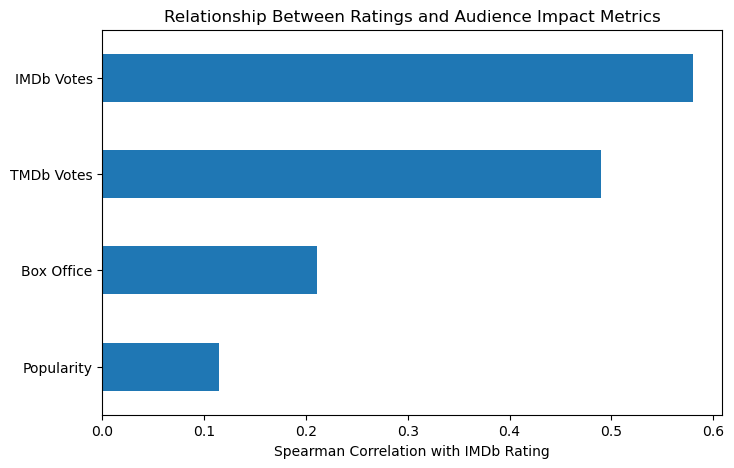

In [28]:
correlations = pd.Series({
    "IMDb Votes": 0.580,
    "TMDb Votes": 0.490,
    "Box Office": 0.211,
    "Popularity": 0.115
})

plt.figure(figsize=(8,5))

correlations.sort_values().plot(
    kind="barh"
)

plt.xlabel("Spearman Correlation with IMDb Rating")
plt.title("Relationship Between Ratings and Audience Impact Metrics")

plt.show()

In [29]:
#The analysis indicates that audience ratings are most strongly associated with engagement metrics such as vote counts. 
# Movies with higher IMDb ratings consistently received more votes on both IMDb and TMDb. 
# However, ratings showed only weak relationships with popularity scores and box-office revenue, 
# suggesting that audience approval does not necessarily translate into widespread visibility or commercial success.

In [30]:
#Genre-specific patterns
eda_df.groupby("Primary Genre")[
    ["IMDb Rating",
     "IMDb Votes",
     "Box Office"]
].mean()

,IMDb Rating,IMDb Votes,Box Office
Primary Genre,,,
Action,6.818182,357598.387097,1.708863e+08
Adventure,6.969863,541604.041096,2.732932e+08
Animation,7.468966,366211.224138,1.783148e+08
Comedy,6.194737,195410.672414,1.285011e+08
Crime,7.111765,460383.294118,1.283992e+08
Documentary,5.150000,812.000000,3.015600e+04
Drama,6.754717,272089.192661,6.084956e+07
Family,6.625000,225380.750000,2.938075e+08
Fantasy,6.923810,435477.047619,1.953532e+08


In [31]:
eda_df.groupby("Primary Genre").size().sort_values(ascending=False)

Primary Genre
Action             179
Drama              121
Adventure           80
Horror              77
Comedy              74
Animation           65
Romance             48
Thriller            45
Science Fiction     38
Fantasy             22
Crime               19
Family              17
Mystery             11
History              7
Documentary          4
War                  4
Music                3
Western              1
dtype: int64

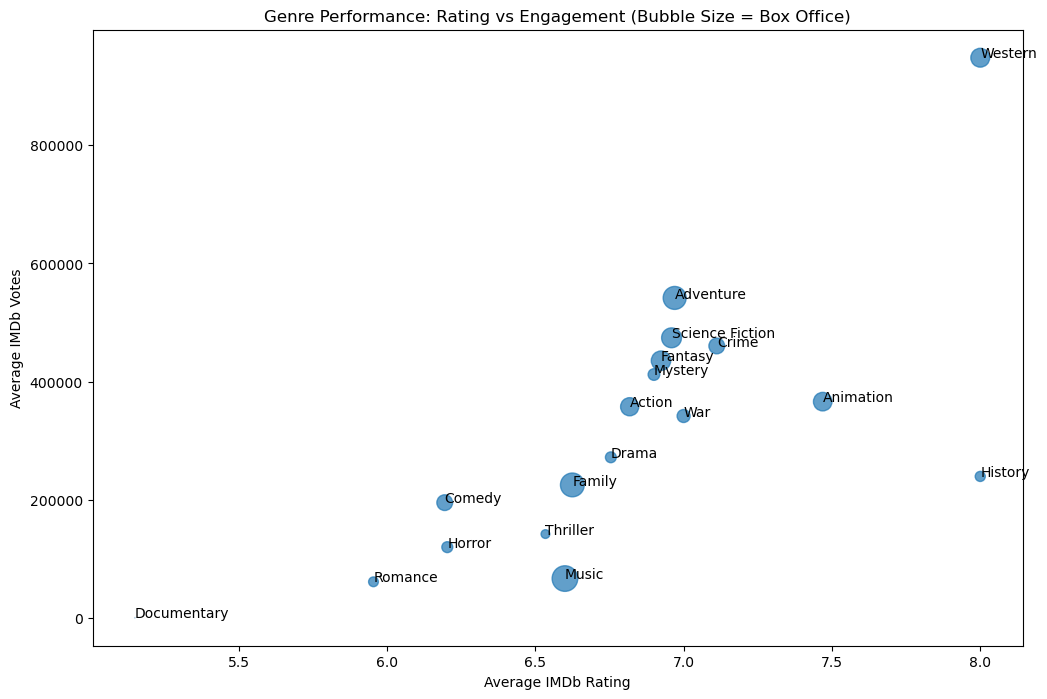

In [32]:
genre_summary = (
    eda_df.groupby("Primary Genre")
      .agg({
          "IMDb Rating":"mean",
          "IMDb Votes":"mean",
          "Box Office":"mean"
      })
      .reset_index()
)

plt.figure(figsize=(12,8))

plt.scatter(
    genre_summary["IMDb Rating"],
    genre_summary["IMDb Votes"],
    s=genre_summary["Box Office"] / 1e6,
    alpha=0.7
)

for _, row in genre_summary.iterrows():
    plt.text(
        row["IMDb Rating"],
        row["IMDb Votes"],
        row["Primary Genre"]
    )

plt.xlabel("Average IMDb Rating")
plt.ylabel("Average IMDb Votes")
plt.title("Genre Performance: Rating vs Engagement (Bubble Size = Box Office)")
plt.show()

In [33]:
#1.High Rating + High Engagement + High Revenue
#Adventure
#Science Fiction
#Animation
#2.High Rating + Moderate Revenue
#Drama
#Crime
#3Moderate Rating + High Revenue
#Family

In [34]:
spearmanr(eda_df['Budget'], eda_df['Box Office'])

SignificanceResult(statistic=nan, pvalue=nan)

In [35]:
eda_df[['Budget', 'Box Office']].isna().sum()

Budget        268
Box Office    317
dtype: int64

In [36]:
temp = eda_df[['Budget', 'Box Office']].dropna()

print(temp.shape)

(475, 2)


In [37]:
rho, p = spearmanr(temp['Budget'], temp['Box Office'])

print(rho, p)

0.736644331287974 2.2193223822438068e-82


In [38]:
eda_with_scraping_df = pd.read_csv("movie_data_with_scraping.csv")

In [39]:
eda_with_scraping_df["has_awards"].value_counts(dropna=False)

has_awards
NaN      765
True      38
False     12
Name: count, dtype: int64

In [40]:
eda_with_scraping_df["Awards Text"].dropna().head(20)

4      The Unknown Man - Wikipedia Jump to content Ma...
53     Scary Movie - Wikipedia Jump to content Main m...
54     List of accolades received by Interstellar - W...
62     Real Steel - Wikipedia Jump to content Main me...
66     List of accolades received by Avengers: Infini...
70     After We Fell - Wikipedia Jump to content Main...
77     Mortal Kombat - Wikipedia Jump to content Main...
79     Room in Rome - Wikipedia Jump to content Main ...
81     Scary Movie 5 - Wikipedia Jump to content Main...
86     List of accolades received by The Dark Knight ...
92     Harry Potter and the Philosopher's Stone - Wik...
97     Apocalypto - Wikipedia Jump to content Main me...
101    Scary Movie 2 - Wikipedia Jump to content Main...
103    The Lord of the Rings: The Return of the King ...
104    List of accolades received by Toy Story 4 - Wi...
112    List of accolades received by Spider-Man: No W...
116    The Lord of the Rings: The Fellowship of the R...
122    List of accolades receiv

In [41]:
eda_with_scraping_df.head()

,TMDb_ID,IMDb_ID,Title,Year,Genre,Primary Genre,TMDb Rating,TMDb Votes,Popularity,Revenue,Budget,Runtime,IMDb Rating,IMDb Votes,Box Office,Wikipedia Page Found,Wikipedia URL,Awards Text,has_awards
0,1339713,tt37287335,Obsession,2026,"Horror, Thriller",Horror,7.917,841,581.7554,297445815.0,750000.0,108,8.2,50183.0,104757650.0,NaN,NaN,NaN,NaN
1,931285,tt17490712,Mortal Kombat II,2026,"Action, Fantasy, Adventure",Action,7.988,1449,519.4298,128857238.0,80000000.0,116,6.7,36627.0,77767462.0,NaN,NaN,NaN,NaN
2,936075,tt11378946,Michael,2026,"Music, Drama",Music,8.653,2635,503.0910,934009960.0,250000000.0,128,7.7,107813.0,340068767.0,NaN,NaN,NaN,NaN
3,1367220,tt33988385,Karuppu,2026,"Action, Fantasy",Action,7.059,17,384.3573,3345079.0,16000000.0,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,879945,tt16288638,The Unknown Man,2021,Drama,Drama,7.800,9,325.1904,NaN,NaN,23,7.0,53.0,NaN,True,https://en.wikipedia.org/wiki/The_Unknown_Man,The Unknown Man - Wikipedia Jump to content Ma...,True


In [42]:
#has_awards contains True/False
eda_with_scraping_df["has_awards"].value_counts(dropna=False)

has_awards
NaN      765
True      38
False     12
Name: count, dtype: int64

In [46]:
#Awards vs Rating
eda_with_scraping_df.groupby("has_awards")["IMDb Rating"].mean()

has_awards
False    5.900000
True     7.221053
Name: IMDb Rating, dtype: float64

In [47]:
#Awards vs Engagement
eda_with_scraping_df.groupby("has_awards")["IMDb Votes"].mean()

has_awards
False    227660.090909
True     849320.000000
Name: IMDb Votes, dtype: float64

In [49]:
#Awards vs Commercial Success
eda_with_scraping_df.groupby("has_awards")["Box Office"].mean()

has_awards
False    1.445046e+08
True     2.667109e+08
Name: Box Office, dtype: float64

In [53]:
comparison = pd.DataFrame({
    'IMDb Rating': eda_with_scraping_df.groupby('has_awards')['IMDb Rating'].mean(),
    'IMDb Votes': eda_with_scraping_df.groupby('has_awards')['IMDb Votes'].mean(),
    'Box Office': eda_with_scraping_df.groupby('has_awards')['Box Office'].mean()
})

print(comparison)

            IMDb Rating     IMDb Votes    Box Office
has_awards                                          
False          5.900000  227660.090909  1.445046e+08
True           7.221053  849320.000000  2.667109e+08


In [54]:
print(comparison.columns)

Index(['IMDb Rating', 'IMDb Votes', 'Box Office'], dtype='str')


In [55]:
multipliers = comparison.loc[True] / comparison.loc[False]

print(multipliers)

IMDb Rating    1.223907
IMDb Votes     3.730649
Box Office     1.845692
dtype: float64


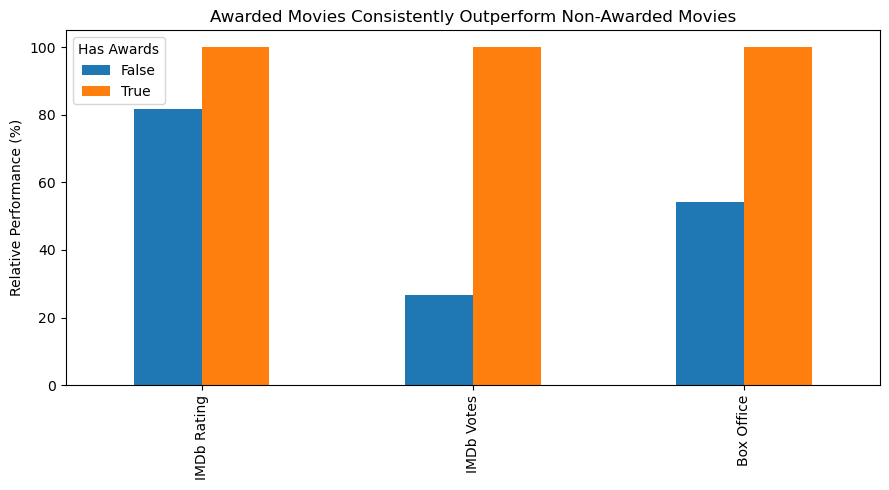

In [56]:
normalized = comparison.copy()

for col in normalized.columns:
    normalized[col] = normalized[col] / normalized[col].max() * 100

normalized.T.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title(
    'Awarded Movies Consistently Outperform Non-Awarded Movies'
)

plt.ylabel('Relative Performance (%)')

plt.legend(title='Has Awards')

plt.tight_layout()
plt.show()

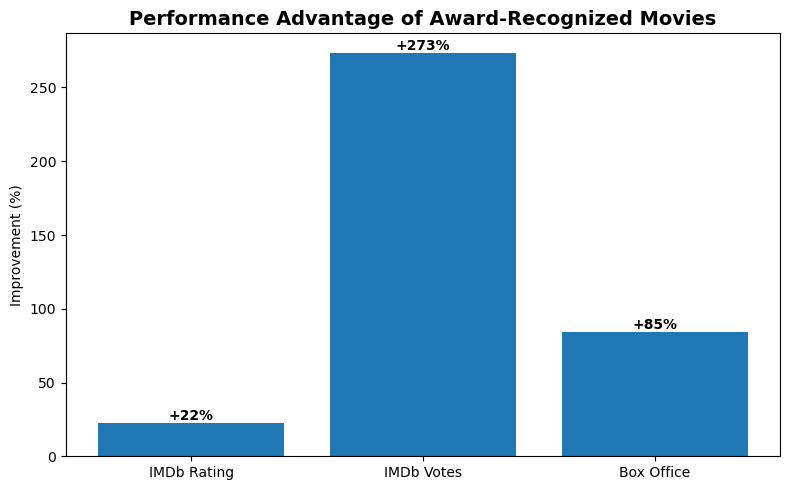

In [57]:
improvement = (
    (comparison.loc[True] - comparison.loc[False])
    / comparison.loc[False]
    * 100
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    improvement.index,
    improvement.values
)

plt.title(
    'Performance Advantage of Award-Recognized Movies',
    fontsize=14,
    weight='bold'
)

plt.ylabel('Improvement (%)')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'+{bar.get_height():.0f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()